In [5]:
import pandas as pd

print("Python is working!")
print("Pandas version:", pd.__version__)

Python is working!
Pandas version: 3.0.2


In [6]:
import pandas as pd

file_path = "../dataset/processed.cleveland.data"

df = pd.read_csv(file_path, header=None)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (303, 14)


In [7]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [8]:
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df.columns = columns

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [10]:
df.dtypes


age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca              str
thal            str
target        int64
dtype: object

In [11]:
print("Unique values in ca:")
print(df["ca"].unique())

print("\nUnique values in thal:")
print(df["thal"].unique())

Unique values in ca:
<StringArray>
['0.0', '3.0', '2.0', '1.0', '?']
Length: 5, dtype: str

Unique values in thal:
<StringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str


In [12]:
print("Missing values in ca:", (df["ca"] == "?").sum())
print("Missing values in thal:", (df["thal"] == "?").sum())

Missing values in ca: 4
Missing values in thal: 2


In [13]:
import numpy as np

df = df.replace("?", np.nan)

print("Missing values after conversion:")
print(df.isnull().sum())


Missing values after conversion:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [14]:
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

print(df[["ca", "thal"]].dtypes)

ca      float64
thal    float64
dtype: object


In [15]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

ca      4
thal    2
dtype: int64


In [16]:
print("CA distribution:")
print(df["ca"].value_counts(dropna=False).sort_index())

print("\nThal distribution:")
print(df["thal"].value_counts(dropna=False).sort_index())

CA distribution:
ca
0.0    176
1.0     65
2.0     38
3.0     20
NaN      4
Name: count, dtype: int64

Thal distribution:
thal
3.0    166
6.0     18
7.0    117
NaN      2
Name: count, dtype: int64


In [17]:
print("Target values:")
print(df["target"].value_counts().sort_index())

print("\nTarget data type:")
print(df["target"].dtype)

Target values:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Target data type:
int64


In [18]:
df["target_original"] = df["target"]

print(df[["target", "target_original"]].head())


   target  target_original
0       0                0
1       2                2
2       1                1
3       0                0
4       0                0


In [19]:
df["target"] = (df["target"] > 0).astype(int)

print("Binary target distribution:")
print(df["target"].value_counts().sort_index())

Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [20]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (303, 15)

Missing values:
age                0
sex                0
cp                 0
trestbps           0
chol               0
fbs                0
restecg            0
thalach            0
exang              0
oldpeak            0
slope              0
ca                 4
thal               2
target             0
target_original    0
dtype: int64

Data types:
age                float64
sex                float64
cp                 float64
trestbps           float64
chol               float64
fbs                float64
restecg            float64
thalach            float64
exang              float64
oldpeak            float64
slope              float64
ca                 float64
thal               float64
target               int64
target_original      int64
dtype: object


In [21]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [22]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (303, 15)

Missing values:
age                0
sex                0
cp                 0
trestbps           0
chol               0
fbs                0
restecg            0
thalach            0
exang              0
oldpeak            0
slope              0
ca                 4
thal               2
target             0
target_original    0
dtype: int64

Data types:
age                float64
sex                float64
cp                 float64
trestbps           float64
chol               float64
fbs                float64
restecg            float64
thalach            float64
exang              float64
oldpeak            float64
slope              float64
ca                 float64
thal               float64
target               int64
target_original      int64
dtype: object


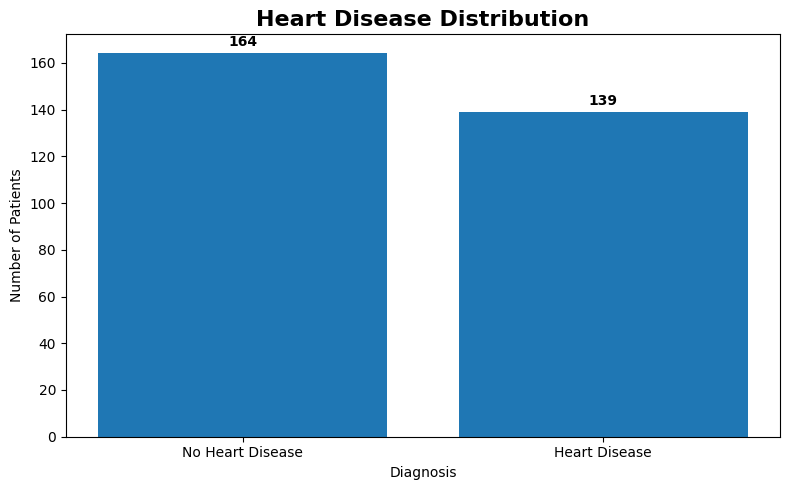

In [23]:
import matplotlib.pyplot as plt

target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    ["No Heart Disease", "Heart Disease"],
    target_counts.values
)

plt.title("Heart Disease Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        str(int(height)),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [26]:
print("Average age:")
print(df.groupby("target")["age"].mean())

print("\nMedian age:")
print(df.groupby("target")["age"].median())


Average age:
target
0    52.585366
1    56.625899
Name: age, dtype: float64

Median age:
target
0    52.0
1    58.0
Name: age, dtype: float64


In [27]:
print("Average age:")
print(df.groupby("target")["age"].mean())

print("\nMedian age:")
print(df.groupby("target")["age"].median())

Average age:
target
0    52.585366
1    56.625899
Name: age, dtype: float64

Median age:
target
0    52.0
1    58.0
Name: age, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_3192\1677331191.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


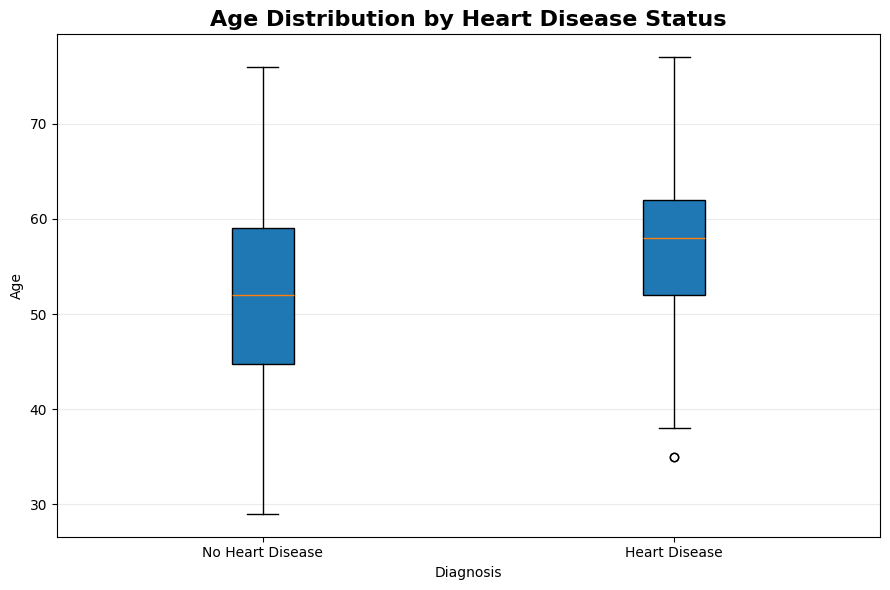

In [28]:
plt.figure(figsize=(9, 6))

data_to_plot = [
    df[df["target"] == 0]["age"],
    df[df["target"] == 1]["age"]
]

box = plt.boxplot(
    data_to_plot,
    labels=["No Heart Disease", "Heart Disease"],
    patch_artist=True
)

plt.title(
    "Age Distribution by Heart Disease Status",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Diagnosis")
plt.ylabel("Age")

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [29]:
cp_analysis = (
    df.groupby("cp")["target"]
    .agg(["count", "sum"])
    .reset_index()
)

cp_analysis["heart_disease_rate"] = (
    cp_analysis["sum"] / cp_analysis["count"] * 100
)

cp_analysis

,cp,count,sum,heart_disease_rate
0,1.0,23,7,30.434783
1,2.0,50,9,18.000000
2,3.0,86,18,20.930233
3,4.0,144,105,72.916667


In [30]:
cp_analysis[["cp", "heart_disease_rate"]]

,cp,heart_disease_rate
0,1.0,30.434783
1,2.0,18.000000
2,3.0,20.930233
3,4.0,72.916667


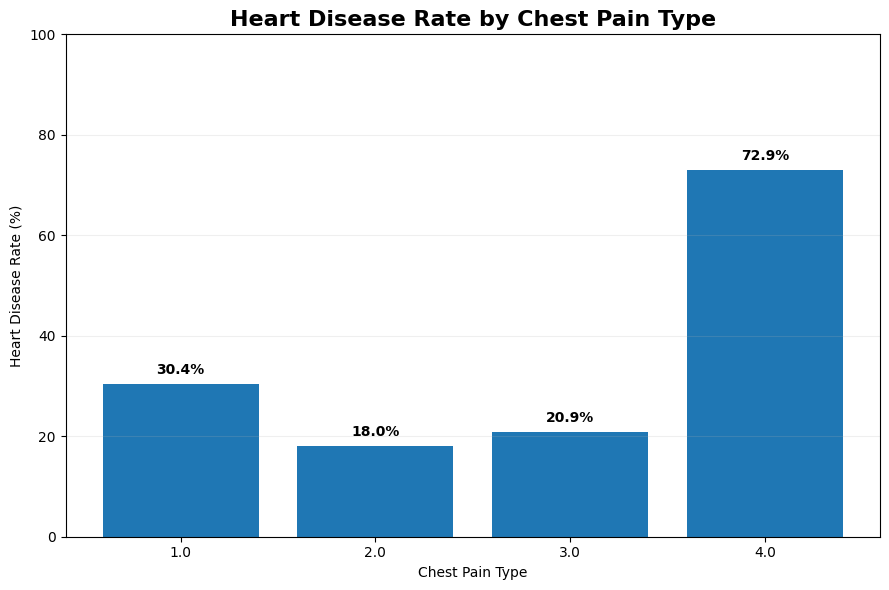

In [31]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    cp_analysis["cp"].astype(str),
    cp_analysis["heart_disease_rate"]
)

plt.title(
    "Heart Disease Rate by Chest Pain Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Chest Pain Type")
plt.ylabel("Heart Disease Rate (%)")
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{height:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [32]:
cp_analysis


,cp,count,sum,heart_disease_rate
0,1.0,23,7,30.434783
1,2.0,50,9,18.000000
2,3.0,86,18,20.930233
3,4.0,144,105,72.916667


In [ ]:
print("Average maximum heart rate:")
print(df.groupby("target")["thalach"].mean())

print("\nMedian maximum heart rate:")
print(df.groupby("target")["thalach"].median())

Average maximum heart rate:
target
0    158.378049
1    139.258993
Name: thalach, dtype: float64

Median maximum heart rate:
target
0    161.0
1    142.0
Name: thalach, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_3192\901085047.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


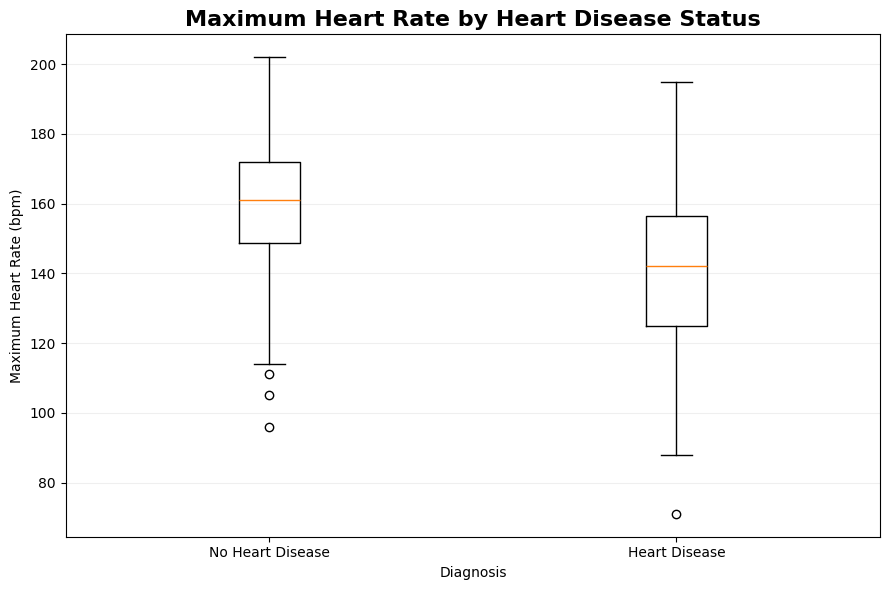

In [33]:
plt.figure(figsize=(9, 6))

data_to_plot = [
    df[df["target"] == 0]["thalach"],
    df[df["target"] == 1]["thalach"]
]

plt.boxplot(
    data_to_plot,
    labels=["No Heart Disease", "Heart Disease"]
)

plt.title(
    "Maximum Heart Rate by Heart Disease Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Diagnosis")
plt.ylabel("Maximum Heart Rate (bpm)")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [34]:
correlation = (
    df.drop(columns=["target_original"])
      .corr(numeric_only=True)["target"]
      .sort_values(ascending=False)
)

print(correlation)

target      1.000000
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


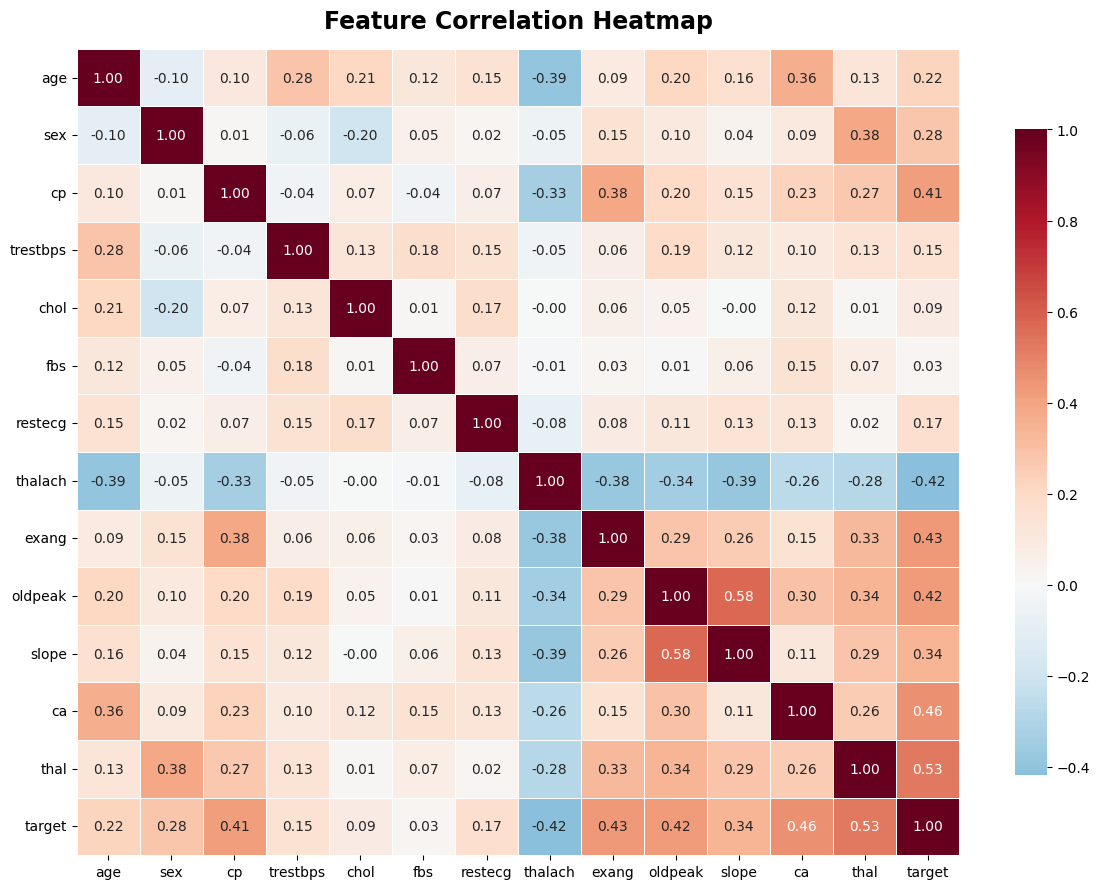

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

corr_matrix = df.drop(columns=["target_original"]).corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

In [36]:
exang_analysis = (
    df.groupby("exang")["target"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

exang_analysis["heart_disease_rate"] = exang_analysis["mean"] * 100

exang_analysis[
    ["exang", "count", "sum", "heart_disease_rate"]
]

,exang,count,sum,heart_disease_rate
0,0.0,204,63,30.882353
1,1.0,99,76,76.767677


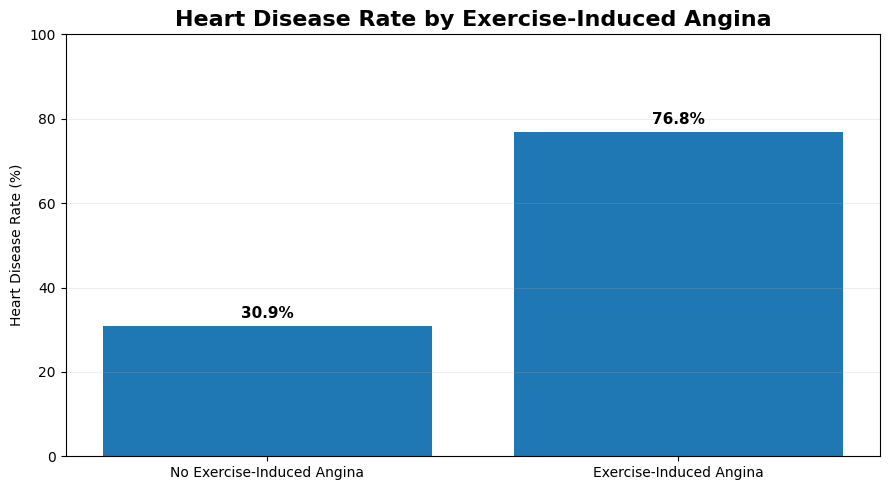

In [37]:
labels = ["No Exercise-Induced Angina", "Exercise-Induced Angina"]
rates = [30.88, 76.77]

plt.figure(figsize=(9, 5))

bars = plt.bar(labels, rates)

plt.title(
    "Heart Disease Rate by Exercise-Induced Angina",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Heart Disease Rate (%)")
plt.ylim(0, 100)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 2,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [38]:
eda_summary = df.groupby("target")[
    ["age", "trestbps", "chol", "thalach", "oldpeak"]
].mean().round(2)

eda_summary.index = ["No Heart Disease", "Heart Disease"]

eda_summary

,age,trestbps,chol,thalach,oldpeak
No Heart Disease,52.59,129.25,242.64,158.38,0.59
Heart Disease,56.63,134.57,251.47,139.26,1.57


In [39]:
X = df.drop(columns=["target", "target_original"])
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features shape: (303, 13)
Target shape: (303,)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (242, 13)
Testing features: (61, 13)
Training target: (242,)
Testing target: (61,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (242, 13)
Testing features: (61, 13)
Training target: (242,)
Testing target: (61,)


In [42]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

X_train_imputed[["ca", "thal"]] = imputer.fit_transform(
    X_train[["ca", "thal"]]
)

X_test_imputed[["ca", "thal"]] = imputer.transform(
    X_test[["ca", "thal"]]
)

print("Missing values in training data:",
      X_train_imputed.isnull().sum().sum())

print("Missing values in testing data:",
      X_test_imputed.isnull().sum().sum())

Missing values in training data: 0
Missing values in testing data: 0


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (242, 13)
Testing data shape: (61, 13)


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", round(log_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 86.89 %

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_imputed, y_train)

y_pred_rf = rf_model.predict(X_test_imputed)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 90.16 %

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



In [46]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train_imputed, y_train)

y_pred_dt = dt_model.predict(X_test_imputed)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 78.69 %

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        33
           1       0.73      0.86      0.79        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



In [ ]:
Decision Tree Accuracy: 78.69 %

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        33
           1       0.73      0.86      0.79        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61


In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

log_cv_model = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

rf_cv_model = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

dt_cv_model = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

models = {
    "Logistic Regression": log_cv_model,
    "Random Forest": rf_cv_model,
    "Decision Tree": dt_cv_model
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    print(
        f"{name}: {scores.mean() * 100:.2f}% "
        f"(± {scores.std() * 100:.2f}%)"
    )

Logistic Regression: 82.83% (± 3.60%)
Random Forest: 81.49% (± 5.26%)
Decision Tree: 76.89% (± 7.13%)


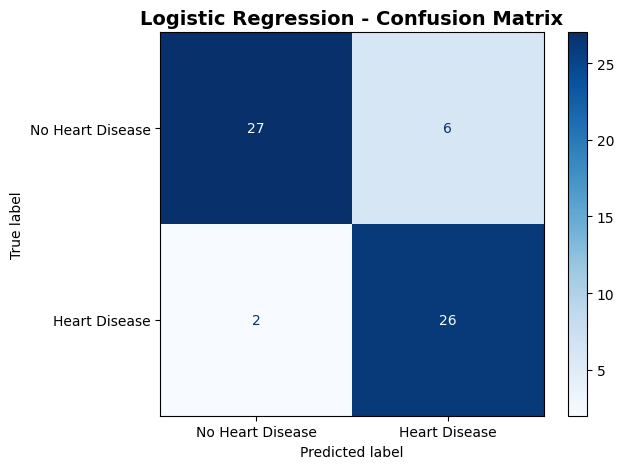

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title(
    "Logistic Regression - Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

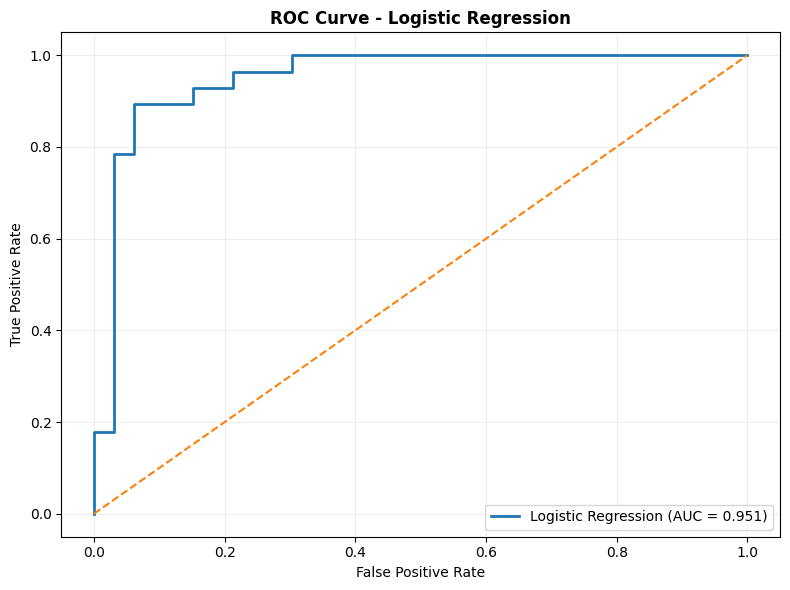

ROC-AUC Score: 0.951


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
auc_score = roc_auc_score(y_test, y_prob_log)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression", fontweight="bold")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", round(auc_score, 3))

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

final_model.fit(X, y)

joblib.dump(final_model, "../models/heart_disease_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!
